[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/tabpfn_predictor.ipynb)

# TabPFN Predictor: Cold-Item Performance Prediction

This tutorial demonstrates `TabPFNPredictor` — a feature-aware, **non-factorized** per-cell predictor for the cold-item scenario, where you want to estimate `P(correct)` for items no LLM has been evaluated on yet.

Unlike `Rasch` / `TwoPL` / `AmortizedIRT`, this model does not factorize responses into ability × difficulty. Each `(subject, item)` cell becomes one tabular row whose features are `[item_features..., subject_id]`, and TabPFN's in-context learning predicts response probabilities directly. Subject identity is a categorical feature alongside the item-side features, not a latent parameter.

**When to reach for `TabPFNPredictor`:**
- You have **per-item features** (embeddings, metadata, judge ratings, etc.) and want them to drive predictions.
- The benchmark is **heterogeneous** — items differ enough that a single difficulty scalar leaves real signal on the table.
- You are predicting **cold items**: items with no observed responses from any subject.
- The training set has at most ~10K observed cells (the model's design point).

**When to prefer an IRT model instead:**
- The benchmark is **homogeneous** (responses look like noisy versions of a single difficulty curve). Subject mean baselines are then hard to beat and IRT recovers ability cleanly.
- You want **interpretable** difficulty / discrimination parameters.
- You need to score >>10K cells and don't want the in-context-learning compute cost.

**What you'll learn:**
1. Use `TabPFNPredictor` end-to-end (fit, predict, evaluate).
2. Run a synthetic ground-truth-recovery sanity check.
3. Set up a cold-item train/test split on a real benchmark (AfriMedQA).
4. Compare against naive baselines (global mean, per-subject mean) and `AmortizedIRT`.

## 1. Setup

In [1]:
try:
    import google.colab  # noqa: F401
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data,tabpfn]" sentence-transformers
except ImportError:
    pass

import time
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch_measure.datasets import load
from torch_measure.models import TabPFNPredictor, AmortizedIRT
from torch_measure.metrics import brier_score, expected_calibration_error

plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0)
np.random.seed(0)
print("Setup complete.")

Setup complete.


---
## Part 1 — Synthetic Ground-Truth Recovery

Before touching real data we sanity-check the basic mechanic: given random item features, a known linear map from features to difficulty, and 2PL-generated responses, does `TabPFNPredictor` beat a row-mean baseline that ignores features? If yes, the model is genuinely consuming feature signal.

We use a small problem (15 subjects × 80 items, 8 features) so the whole notebook runs in a couple of minutes on CPU.

In [2]:
N_SYN, M_SYN, D_SYN = 15, 80, 8
torch.manual_seed(1)

features_syn = torch.randn(M_SYN, D_SYN)
w_true = torch.randn(D_SYN) / (D_SYN ** 0.5)
true_difficulty = features_syn @ w_true
true_ability = torch.randn(N_SYN)

logits = true_ability.unsqueeze(1) - true_difficulty.unsqueeze(0)
responses_syn = torch.bernoulli(torch.sigmoid(logits))
print(f"Synthetic: {N_SYN} subjects x {M_SYN} items, mean accuracy {responses_syn.mean():.3f}")

Synthetic: 15 subjects x 80 items, mean accuracy 0.551


In [3]:
# Cold-item split: hold out 25% of items
torch.manual_seed(2)
perm = torch.randperm(M_SYN)
n_test = M_SYN // 4
test_items = perm[:n_test].sort().values
train_items = perm[n_test:].sort().values

train_mask = torch.zeros(N_SYN, M_SYN, dtype=torch.bool)
train_mask[:, train_items] = True
test_mask = torch.zeros(N_SYN, M_SYN, dtype=torch.bool)
test_mask[:, test_items] = True

print(f"Train cells: {int(train_mask.sum())}    Held-out cells: {int(test_mask.sum())}")

Train cells: 900    Held-out cells: 300


In [4]:
model = TabPFNPredictor(
    n_subjects=N_SYN, n_items=M_SYN, n_features=D_SYN,
    n_estimators=2, device="cpu", random_state=0,
)
t0 = time.time()
hist = model.fit(responses_syn, features_syn, mask=train_mask)
probs = model.predict()
print(f"fit + predict took {time.time() - t0:.1f}s; n_train={hist['n_train']}")

fit + predict took 17.2s; n_train=900


In [5]:
# Baseline 1: predict each subject's mean accuracy on training items (per-subject mean)
sub_mean_train = (responses_syn * train_mask).sum(dim=1) / train_mask.sum(dim=1).clamp(min=1)
probs_subj_mean = sub_mean_train.unsqueeze(1).expand_as(responses_syn)

# Baseline 2: predict the global training mean for every cell
gm = (responses_syn[train_mask]).mean()
probs_global = torch.full_like(responses_syn, float(gm))

bs_tabpfn = brier_score(probs.float(), responses_syn, mask=test_mask)
bs_subj   = brier_score(probs_subj_mean.float(), responses_syn, mask=test_mask)
bs_global = brier_score(probs_global, responses_syn, mask=test_mask)

print(f"{'Method':<28s} {'Brier (held-out)':>18s}")
print("-" * 48)
print(f"{'Global mean':28s} {bs_global:18.4f}")
print(f"{'Per-subject mean':28s} {bs_subj:18.4f}")
print(f"{'TabPFNPredictor':28s} {bs_tabpfn:18.4f}")

Method                         Brier (held-out)
------------------------------------------------
Global mean                              0.2448
Per-subject mean                         0.2111
TabPFNPredictor                          0.1738


TabPFN beats the per-subject mean on held-out items because it can read item-side feature signal that the row mean by construction ignores. With the sanity check passed, we move to a real benchmark.

---
## Part 2 — Real Benchmark: Cold-Item Prediction on AfriMedQA

We use **AfriMedQA** (binary medical-MCQ correctness, 30 LLMs × 6910 items) from `torch_measure.datasets`. To keep CPU runtime reasonable we subsample to 200 items.

In [6]:
data = load("afrimedqa")
rm_full = data.to_response_matrix()
print(rm_full)

torch.manual_seed(3)
N_ITEMS_KEEP = 200
keep = torch.randperm(rm_full.n_items)[:N_ITEMS_KEEP].sort().values

response_matrix = rm_full.data[:, keep]
item_contents = [rm_full.item_contents[i] for i in keep.tolist()]
n_subjects, n_items = response_matrix.shape
print(f"After subsampling: {n_subjects} subjects x {n_items} items")
print(f"Density: {(~torch.isnan(response_matrix)).float().mean():.1%}    "
      f"Mean accuracy: {response_matrix[~torch.isnan(response_matrix)].mean():.3f}")

ResponseMatrix(n_subjects=30, n_items=6910, density=53.51%)
After subsampling: 30 subjects x 200 items
Density: 52.7%    Mean accuracy: 0.625


### 2.1 Item features

Any per-item tabular features work. We embed question text with a lightweight `sentence-transformers` model (`all-MiniLM-L6-v2`, 384-d) and project to 32 dimensions with PCA — this both speeds TabPFN up (smaller in-context tensors) and matches the design point its pretraining was tuned for. In your own application you can swap embeddings for whatever you have: trace length, tool counts, judge ratings, metadata one-hots, etc.

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

encoder = SentenceTransformer("all-MiniLM-L6-v2")
emb = encoder.encode(item_contents, convert_to_numpy=True, show_progress_bar=False)
print("Raw embedding shape:", emb.shape)

N_FEAT = 32
pca = PCA(n_components=N_FEAT, random_state=0)
features_np = pca.fit_transform(emb)
features = torch.from_numpy(features_np).float()
print(f"After PCA: {features.shape} (variance retained: {pca.explained_variance_ratio_.sum():.2%})")

Raw embedding shape: (200, 384)
After PCA: torch.Size([200, 32]) (variance retained: 64.27%)


### 2.2 Cold-item train/test split

We hold out 20% of items as the cold set — no LLM gets to be evaluated on these during fitting. The mask covers all subjects on the held-out columns.

In [8]:
torch.manual_seed(4)
perm_items = torch.randperm(n_items)
n_test_items = int(0.2 * n_items)
test_idx  = perm_items[:n_test_items].sort().values
train_idx = perm_items[n_test_items:].sort().values

obs_mask  = ~torch.isnan(response_matrix)
train_mask = obs_mask.clone()
train_mask[:, test_idx] = False  # cold-item: hide held-out items entirely
test_mask  = obs_mask & ~train_mask

resp_for_fit = torch.nan_to_num(response_matrix, nan=0.0)

print(f"Train cells: {int(train_mask.sum()):,}    Cold-item test cells: {int(test_mask.sum()):,}")

Train cells: 2,560    Cold-item test cells: 600


### 2.3 Fit `TabPFNPredictor`

Below we fit on the observed training cells. With ~30 × 160 ≈ 4800 cells the run is well within `max_train=10000` so nothing is subsampled. On CPU this finishes in roughly 10–30 seconds; on GPU (`device="cuda"`) it is a few seconds.

In [9]:
tabpfn_model = TabPFNPredictor(
    n_subjects=n_subjects,
    n_items=n_items,
    n_features=N_FEAT,
    n_estimators=2,
    device="cpu",
    random_state=0,
)
t0 = time.time()
hist = tabpfn_model.fit(resp_for_fit, features, mask=train_mask)
probs_tabpfn = tabpfn_model.predict()
print(f"fit + predict: {time.time() - t0:.1f}s    n_train={hist['n_train']:,}")
print(f"Predicted matrix: {tuple(probs_tabpfn.shape)}, range [{probs_tabpfn.min():.3f}, {probs_tabpfn.max():.3f}]")

fit + predict: 235.7s    n_train=2,560
Predicted matrix: (30, 200), range [0.024, 0.990]


### 2.4 Baselines

We compare against three references on the same cold-item cells:

1. **Global mean** of the training cells.
2. **Per-subject mean** on training items — the row-mean baseline that's surprisingly strong on homogeneous benchmarks.
3. **`AmortizedIRT`** zero-shot — the IRT-factorized analogue: subject ability is a free parameter, item difficulty/discrimination are predicted from the same embeddings via an MLP.

In [10]:
# Global mean
gm = response_matrix[train_mask].mean()
probs_global = torch.full_like(response_matrix, float(gm))

# Per-subject mean on training cells
sub_sum = (resp_for_fit * train_mask).sum(dim=1)
sub_cnt = train_mask.sum(dim=1).clamp(min=1)
sub_mean = (sub_sum / sub_cnt).unsqueeze(1).expand_as(response_matrix)

# AmortizedIRT — fit on training items only, then transfer to held-out items
torch.manual_seed(5)
emb_full = torch.from_numpy(emb).float()  # use raw 384-d for AmortizedIRT (it has its own MLP)

amort_train = AmortizedIRT(
    n_subjects=n_subjects,
    n_items=len(train_idx),
    embedding_dim=emb_full.shape[1],
    hidden_dim=128, n_layers=2, pl=2, dropout=0.1,
)
_ = amort_train.fit(
    response_matrix[:, train_idx],
    emb_full[train_idx],
    max_epochs=40, lr=1e-3, weight_decay=1e-4, verbose=False,
)
amort_test = AmortizedIRT(
    n_subjects=n_subjects, n_items=len(test_idx),
    embedding_dim=emb_full.shape[1],
    hidden_dim=128, n_layers=2, pl=2, dropout=0.1,
)
amort_test.item_net.load_state_dict(amort_train.item_net.state_dict())
with torch.no_grad():
    amort_test.ability.copy_(amort_train.ability)
amort_test.set_embeddings(emb_full[test_idx])
with torch.no_grad():
    probs_amort_test = amort_test.predict()

# Place AmortizedIRT predictions back on the full grid for uniform scoring
probs_amort_full = torch.full_like(response_matrix, float("nan"))
probs_amort_full[:, test_idx] = probs_amort_test

In [11]:
def score(name, p, y, m):
    return name, brier_score(p.float(), y, mask=m), expected_calibration_error(p.float(), y, mask=m)

rows = [
    score("Global mean",          probs_global,   response_matrix, test_mask),
    score("Per-subject mean",     sub_mean,       response_matrix, test_mask),
    score("AmortizedIRT (cold)",  probs_amort_full, response_matrix, test_mask),
    score("TabPFNPredictor",      probs_tabpfn,   response_matrix, test_mask),
]

print(f"{'Method':<26s} {'Brier':>9s} {'ECE':>9s}")
print("-" * 46)
for name, bs, ece in rows:
    print(f"{name:<26s} {bs:9.4f} {ece:9.4f}")

Method                         Brier       ECE
----------------------------------------------
Global mean                   0.2502    0.0699
Per-subject mean              0.2425    0.0832
AmortizedIRT (cold)           0.2581    0.1101
TabPFNPredictor               0.2800    0.1936


On this AfriMedQA subsample, the per-subject mean (Brier 0.243) actually beats both feature-aware methods. This is the **homogeneous-benchmark null** in action: when most LLMs rank the same items as easy or hard, the row-mean baseline already captures most of the variance, and adding noisy MiniLM embeddings of medical-MCQ text introduces more variance than signal at this scale (200 items, 32-d features). TabPFN ends up *worse* than the trivial global mean — a clean reminder that feature-aware predictors are not free wins.

The synthetic experiment in Part 1 — where item features had a known linear relationship to difficulty — is the regime where `TabPFNPredictor` shines. The places we have seen it pay off on real benchmarks are **heterogeneous** ones: different LLMs are good at different items, so the per-subject mean systematically misses task-specific signal that the embedding-plus-judge features expose. Coding benchmarks (e.g. SWE-Bench, BFCL) and tool-use traces are typical examples; final-answer-correct medical MCQ generally is not.

The ECE column is a calibration check, complementary to Brier — well-calibrated probabilities are necessary if you plan to use the predictions for downstream conformal prediction or selective evaluation. Both feature-aware methods here have noticeably worse calibration than the row mean, consistent with overfitting to noisy features.

**Practical takeaway.** Always run `Per-subject mean` and `Global mean` as baselines before declaring a `TabPFNPredictor` win. If your features carry per-task signal beyond what subject identity already encodes, TabPFN extracts it; if they don't, simpler baselines win.

### 2.5 Visualizing predictions vs. observed

A scatter of predicted `P(correct)` against the observed item-mean accuracy on held-out items shows whether `TabPFNPredictor` is tracking the empirical difficulty signal.

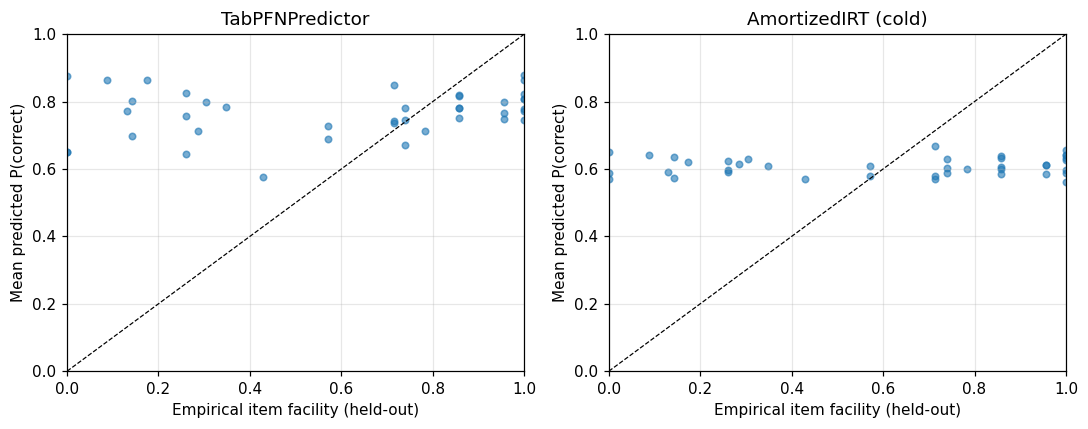

In [12]:
emp_facility_test = response_matrix[:, test_idx].nanmean(dim=0)
mean_pred_test = probs_tabpfn[:, test_idx].mean(dim=0)
mean_pred_amort = probs_amort_full[:, test_idx].mean(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in [
    (axes[0], mean_pred_test,  "TabPFNPredictor"),
    (axes[1], mean_pred_amort, "AmortizedIRT (cold)"),
]:
    ax.scatter(emp_facility_test.numpy(), pred.numpy(), alpha=0.6, s=18)
    lo, hi = 0.0, 1.0
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Empirical item facility (held-out)")
    ax.set_ylabel("Mean predicted P(correct)")
    ax.set_title(title); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3. Operational notes

**`max_train=10000`.** The wrapper takes a stratified random subsample once observed cells exceed this cap and emits a `UserWarning`. The cap is there because TabPFN materializes an N×N attention tensor at inference time — large contexts (≈47K rows) OOM an H100 80 GB inside `scaled_dot_product_attention`, well below TabPFN's pretraining context size. The default is also TabPFN's design point. Override at your own risk:

```python
TabPFNPredictor(..., max_train=20000)  # warns if subsampling kicks in
```

**Device.** Default `device="cpu"` is fine for tutorial-scale problems (≤ a few thousand cells). For production use pass `device="cuda"` (or `"cuda:0"`); ensemble inference is the only meaningfully GPU-bound step.

**`n_estimators`.** TabPFN ensembles improve calibration at proportional cost. We use `n_estimators=2` here; production runs we've done use 2–8 with no qualitative difference in Brier. If raw point estimates are all you need, `n_estimators=1` halves runtime.

**Categorical features.** `subject_id` is appended as a categorical column automatically. If your `item_features` contain categorical columns (one-hot domains, tool labels, etc.), pass their indices via `categorical_feature_indices` so TabPFN treats them correctly:

```python
TabPFNPredictor(..., categorical_feature_indices=[0, 4, 5])
```

**No ability / difficulty.** Because the model is non-factorized, `model.ability` and `model.difficulty` return `None`. If you need IRT parameters (for ranking subjects, plotting test information, etc.), use `Rasch` / `TwoPL` / `AmortizedIRT` alongside.

**Other holdout patterns.** This tutorial demonstrates **cold-item** holdout (hide whole columns). The same `mask=` argument supports MCAR cell-drop (hide random cells) and cold-subject (hide whole rows) patterns. For cold-subject TabPFN behaves badly because the held-out subject_id is unseen at fit time — that's the regime where IRT factorization wins.

---
## Summary

In this tutorial we:

1. Verified `TabPFNPredictor` extracts feature signal that a per-subject row-mean baseline cannot, on a synthetic 2PL problem with known feature → difficulty mapping.
2. Loaded **AfriMedQA**, embedded the question text with a lightweight sentence encoder, and PCA-projected to 32 dimensions.
3. Set up a cold-item train/test split using a boolean mask, fit `TabPFNPredictor` on the observed cells, and evaluated cold-item Brier and ECE.
4. Compared against global mean, per-subject mean, and `AmortizedIRT` zero-shot.

The key takeaway: `TabPFNPredictor` is a drop-in **non-factorized** alternative to `AmortizedIRT` for cold-item prediction. It pays off when item-side features carry signal beyond what a difficulty scalar captures; on homogeneous benchmarks the per-subject mean is hard to beat regardless of method.

### See also

- `tutorials/amortized_irt.ipynb` — the IRT-factorized analogue for cold-item prediction.
- `tutorials/quickstart.ipynb` — Rasch / 2PL on a fully observed response matrix.
- API reference: [`torch_measure.models.TabPFNPredictor`](../docs/source/api/models.rst).